# 5 &middot; Solving the Minimization: Newton vs. Gradient Descent

Time to open the solver box. We pin a beam's left edge, drag its **whole right edge**
toward a target down and to the right, and drive the beam to equilibrium from rest with
two methods that differ only in their search direction, **gradient descent** and
**Newton**. Per iteration we track the energy, the gradient norm
$\lVert\nabla E\rVert$ and the **Newton decrement**
$\lambda = \sqrt{\nabla E^\top H^{-1}\nabla E}$.

$$\Delta x_{\text{GD}} = -\nabla E, \qquad \Delta x_{\text{Newton}} = -H^{-1}\nabla E.$$

Imports, and every tunable parameter of this notebook.

In [1]:
%matplotlib inline
import os
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import igl
import simkit
import utils

NOTEBOOK = "005_numerical_solver"                                  # this file's name
RESULTS_DIR = utils.notebook_results_path(NOTEBOOK) # results/005_numerical_solver/
MEDIA_DIR = "media"                                                # tracked copies for the website
# mesh
NX, NY = 12, 4                          # grid vertices along x and y
WIDTH, HEIGHT = 2.0, 0.4                # beam size
# material: a soft beam
MATERIAL = "macklin-mueller-neo-hookean"   # simkit elastic model (the old utils "Neo-Hookean")
YM, PR = 0.5, 0.45                      # Young's modulus, Poisson ratio
# boundary conditions
K_PIN = 1e2                             # gentle pin spring on the left edge
K_HANDLE = 25.0                         # soft handle spring on the right edge
HANDLE_OFFSET = np.array([0.5, -0.7])   # handle targets = rest right edge + this offset
# solvers
MAX_ITERS = 60                          # iteration cap for both solvers
TOL = 1e-9                              # stop once the step ||alpha dx|| is smaller than this
# finite-difference check
FD_STEP = 1e-6                          # central-difference step
FD_NOISE = 0.05                         # std of the random perturbation of the rest state
SEED = 0                                # RNG seed for that perturbation
# visuals
LIMS = ((-1.2, 1.8), (-1.3, 0.6))       # plot window around the beam and its targets
FPS_NEWTON = 4                          # one frame per Newton iteration
FPS_GD = 10                             # one frame per gradient-descent iteration
PSI_RANGE = (1e-3, 3.0)                 # log color range of the energy-density plots

## The beam

A $2\times0.4$ beam from libigl's unit grid, with the constant operators the energy needs built
once: the deformation Jacobian $J$ (each element's $F$ is a block of $Jx$), the per-element area
and the per-element Lamé parameters. The left-edge vertices are pinned in place and the right-edge
vertices form the handle, aimed at their rest positions shifted by `HANDLE_OFFSET`. The top panel
marks pins (blue), handle (orange) and targets (&times;). The bottom panel shows the per-element
area that weights each element's energy; it is uniform here and sums to the beam's area.

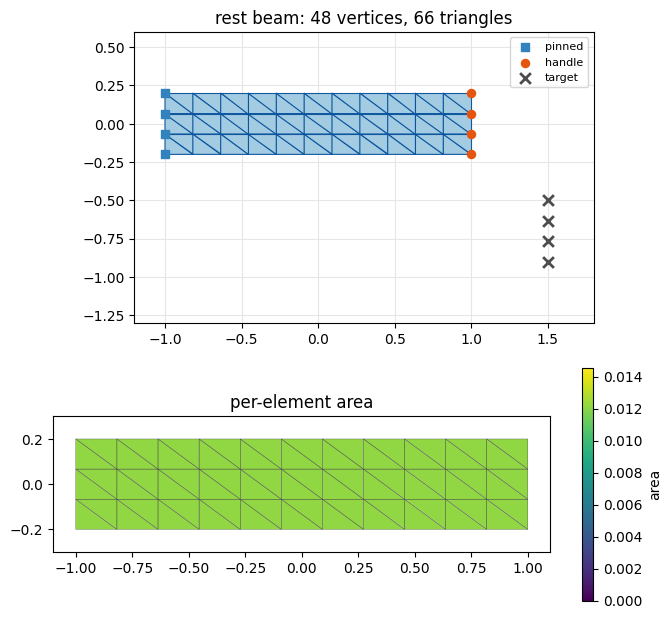

total area = 0.8000  (WIDTH * HEIGHT = 0.8000)


In [2]:
V, T = igl.triangulated_grid(NX, NY)                 # unit square, NX x NY vertices
X = (V - 0.5) * np.array([WIDTH, HEIGHT])            # centered WIDTH x HEIGHT beam
n, dim = X.shape
J = simkit.deformation_jacobian(X, T)                # per-element F = (J @ x).reshape(-1, dim, dim)
vol = simkit.volume(X, T)                            # per-element area
mu, lam = simkit.ympr_to_lame(YM, PR)
mu = np.full((len(T), 1), mu)                        # per-element Lame parameters
lam = np.full((len(T), 1), lam)

pin_idx = np.where(X[:, 0] <= X[:, 0].min() + 1e-6)[0]
handle_idx = np.where(X[:, 0] >= X[:, 0].max() - 1e-6)[0]
handle_targets = X[handle_idx] + HANDLE_OFFSET

fig, axes = plt.subplots(2, 1, figsize=(7, 6.5))
utils.plot_mesh(axes[0], X, T, pins=pin_idx, handles=handle_idx, lims=LIMS,
                title=f"rest beam: {n} vertices, {len(T)} triangles")
axes[0].scatter(*handle_targets.T, marker="x", s=60, linewidths=2, color="0.3", zorder=6,
                label="target")
axes[0].legend(loc="upper right", fontsize=8)
utils.plot_scalar_field(axes[1], X, T, vol, vmin=0.0, vmax=1.2 * vol.max(),
                        title="per-element area", label="area")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "mesh.png"),
                              copy_to=os.path.join(MEDIA_DIR, "005_mesh.png"))
plt.show()
print(f"total area = {vol.sum():.4f}  (WIDTH * HEIGHT = {WIDTH * HEIGHT:.4f})")

## The objective

Elastic energy plus a gentle pin spring and a soft handle spring. The handle spring is kept
**soft**, with forces of the same magnitude as the elastic ones, so the problem is not horribly
ill-conditioned. With a stiff handle, gradient descent just yanks the handle and leaves the rest
of the beam untouched.

$$E(x) = E_{\text{elastic}}(x) + \tfrac{K_{\text{pin}}}{2}\lVert x_{\text{pin}} - p\rVert^2
  + \tfrac{K_{\text{handle}}}{2}\lVert x_{\text{handle}} - h\rVert^2$$

In [3]:
def beam_system(X, J, vol, mu, lam, pin_idx, pin_targets, handle_idx, handle_targets):
    """Neo-Hookean beam + soft pin + soft handle, in stacked vertex positions x."""
    n, dim = X.shape
    Q_pin, b_pin = simkit.dirichlet_penalty(pin_idx, pin_targets, n, K_PIN)
    Q_handle, b_handle = simkit.dirichlet_penalty(handle_idx, handle_targets, n, K_HANDLE)

    def energy_func(x):
        E_elastic = simkit.energies.elastic_energy_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL)
        E_pin = simkit.energies.quadratic_energy(x, Q_pin, b_pin)
        E_handle = simkit.energies.quadratic_energy(x, Q_handle, b_handle)
        E_total = E_elastic + E_pin + E_handle
        return E_total

    def gradient_func(x):
        g_elastic = simkit.energies.elastic_gradient_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL)
        g_pin = simkit.energies.quadratic_gradient(x, Q_pin, b_pin)
        g_handle = simkit.energies.quadratic_gradient(x, Q_handle, b_handle)
        g_total = g_elastic + g_pin + g_handle
        return g_total

    def hessian_func(x):
        H_elastic = simkit.energies.elastic_hessian_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL, psd=True)
        H_pin = simkit.energies.quadratic_hessian(Q_pin)
        H_handle = simkit.energies.quadratic_hessian(Q_handle)
        H_total = H_elastic + H_pin + H_handle
        return H_total

    return energy_func, gradient_func, hessian_func

## The two solvers

simkit's `newton_solver` and `gradient_descent` run the same loop: evaluate $g$ (and $H$), pick
$\Delta x$, choose a step $\alpha$ by backtracking line search (tutorial 6), set
$x \leftarrow x + \alpha\Delta x$, and stop once $\lVert\alpha\Delta x\rVert <$ `TOL` or after
`MAX_ITERS` steps. We run both from the rest state on the *same* objective with
`return_info=True`, which records every step $(\Delta x_k, \alpha_k)$, and then recompute both
first directions at $x_0$ by hand to confirm that the direction is the only difference.

In [4]:
energy_func, gradient_func, hessian_func = beam_system(X, J, vol, mu, lam, pin_idx, X[pin_idx],
                                                       handle_idx, handle_targets)
x0 = X.reshape(-1, 1).copy()
_, newton_info = simkit.solvers.newton_solver(x0, energy_func, gradient_func, hessian_func,
                                              tolerance=TOL, max_iter=MAX_ITERS,
                                              do_line_search=True, return_info=True)
_, gd_info = simkit.solvers.gradient_descent(x0, energy_func, gradient_func,
                                             tolerance=TOL, max_iter=MAX_ITERS,
                                             do_line_search=True, return_info=True)

g0 = gradient_func(x0)
dx_gd = -g0                                                                         # -grad E
dx_newton = sp.sparse.linalg.spsolve(hessian_func(x0).tocsc(), -g0).reshape(-1, 1)  # -H^-1 grad E
cos_angle = (dx_gd.T @ dx_newton).item() / (np.linalg.norm(dx_gd) * np.linalg.norm(dx_newton))
print(f"first recorded step equals the hand-computed direction: "
      f"gradient descent {np.allclose(dx_gd, gd_info['dx'][0])}, "
      f"Newton {np.allclose(dx_newton, newton_info['dx'][0])}")
print(f"|dx_GD| = {np.linalg.norm(dx_gd):.1f}, |dx_Newton| = {np.linalg.norm(dx_newton):.1f}, "
      f"angle between them = {np.degrees(np.arccos(cos_angle)):.0f} deg")

first recorded step equals the hand-computed direction: gradient descent True, Newton True
|dx_GD| = 43.0, |dx_Newton| = 3.6, angle between them = 62 deg


Both recorded first steps are exactly $-\nabla E$ and $-H^{-1}\nabla E$, and already at rest they
disagree: the Newton step is about 12 times shorter and points 62&deg; away from $-\nabla E$. Next,
`iterates` rebuilds $x_0, x_1, \dots$ from the recorded steps and `solver_metrics` measures each
one. It forms $H$ at the gradient-descent iterates only to monitor $\lambda$; gradient descent
itself never forms $H$.

In [5]:
def iterates(x0, info):
    """x_0, x_1, ... rebuilt from the recorded steps x_{k+1} = x_k + alpha_k dx_k."""
    xs = [x0]
    for alpha, dx in zip(info["alphas"], info["dx"]):
        xs.append(xs[-1] + alpha * dx)
    return xs

def solver_metrics(xs):
    """Energy, gradient norm and Newton decrement sqrt(g^T H^-1 g) at every iterate."""
    energy, grad, decrement = [], [], []
    for x in xs:
        g = gradient_func(x)
        H_inv_g = sp.sparse.linalg.spsolve(hessian_func(x).tocsc(), g).reshape(-1, 1)
        energy.append(energy_func(x))
        grad.append(np.linalg.norm(g))
        decrement.append(np.sqrt(max((g.T @ H_inv_g).item(), 0.0)))
    return {"energy": energy, "grad": grad, "decrement": decrement}

newton_xs = iterates(x0, newton_info)
gd_xs = iterates(x0, gd_info)
newton_metrics = solver_metrics(newton_xs)
gd_metrics = solver_metrics(gd_xs)
for name, xs, m in [("Newton", newton_xs, newton_metrics), ("Gradient descent", gd_xs, gd_metrics)]:
    print(f"{name:17s}: {len(xs) - 1:2d} iters, final |grad| = {m['grad'][-1]:.2e}, "
          f"final E - E_Newton = {m['energy'][-1] - newton_metrics['energy'][-1]:.2e}, "
          f"final lambda = {m['decrement'][-1]:.2e}")

Newton           :  6 iters, final |grad| = 2.26e-14, final E - E_Newton = 0.00e+00, final lambda = 2.46e-15
Gradient descent : 60 iters, final |grad| = 6.09e-01, final E - E_Newton = 1.54e-01, final lambda = 5.08e-01


Newton reaches a round-off-level gradient in 6 iterations, while gradient descent uses all 60 and
still sits 0.15 above Newton's energy.

## Checking the derivatives

Both solvers trust `gradient_func`, and Newton also trusts `hessian_func`, so we check them against
central differences (`simkit.gradient_cfd`): the gradient at a randomly perturbed rest state, and
the Hessian there and at Newton's equilibrium $x^\star$. `psd=True` projects each element Hessian to
be positive semi-definite, so that $-H^{-1}\nabla E$ is always a descent direction. The Hessian can
therefore match only where no projection is active.

In [6]:
rng = np.random.default_rng(SEED)
x_pert = x0 + FD_NOISE * rng.standard_normal(x0.shape)
x_star = newton_xs[-1]

g = gradient_func(x_pert)
g_fd = simkit.gradient_cfd(lambda y: np.array([energy_func(y.reshape(-1, 1))]), x_pert.ravel(), FD_STEP)
g_err = np.linalg.norm(g_fd.ravel() - g.ravel()) / np.linalg.norm(g)
print(f"gradient at perturbed rest: rel. error {g_err:.1e}")
for name, x in [("perturbed rest", x_pert), ("equilibrium x*", x_star)]:
    H = hessian_func(x).toarray()
    H_fd = simkit.gradient_cfd(lambda y: gradient_func(y.reshape(-1, 1)).ravel(), x.ravel(), FD_STEP)
    H_err = np.linalg.norm(H_fd - H) / np.linalg.norm(H)
    print(f"Hessian  at {name}: rel. error {H_err:.1e}")

gradient at perturbed rest: rel. error 2.6e-09
Hessian  at perturbed rest: rel. error 4.1e-02
Hessian  at equilibrium x*: rel. error 2.9e-11


The gradient matches to $10^{-9}$, and the Hessian matches at $x^\star$ but differs by 4% at the
perturbed state, where the projection is active.

## Convergence curves

Energy gap to the optimum, gradient norm and Newton decrement per iteration, all on a log scale.

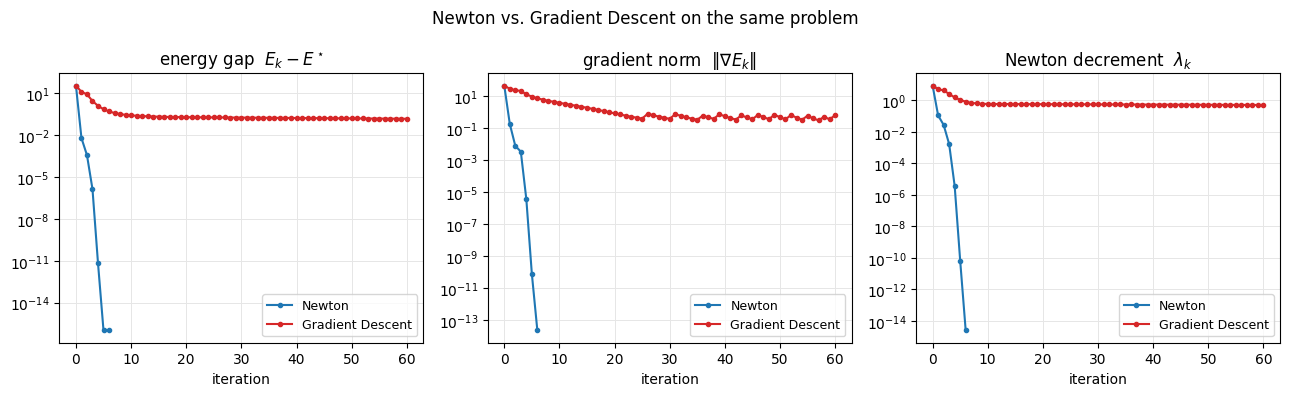

In [7]:
fig, _ = utils.convergence_plot({"Newton": newton_metrics, "Gradient Descent": gd_metrics},
                                title="Newton vs. Gradient Descent on the same problem")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "convergence.png"),
                              copy_to=os.path.join(MEDIA_DIR, "005_convergence.png"))
plt.show()

Newton's curves drop steeply, with the number of correct digits roughly doubling per step at the
end (quadratic convergence). Gradient descent flattens out after about 10 iterations, stalled by the
ill-conditioned elastic Hessian. Its $\lambda$ stays near 0.5, and since $\lambda^2/2$ estimates
$E - E^\star$, that predicts a remaining gap of about 0.13, close to the true 0.15. The accepted
line-search step $\alpha_k$, plotted next, shows why gradient descent stalls.

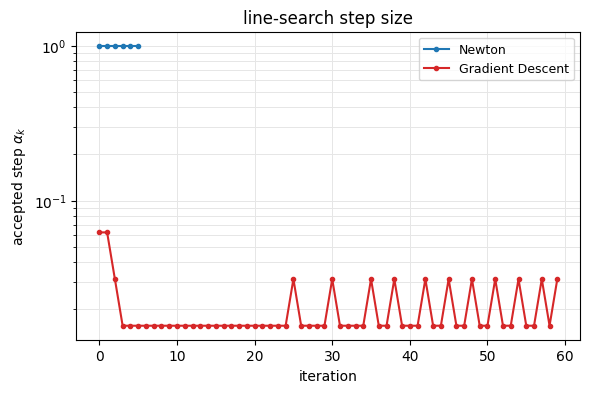

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 4))
for name, info in [("Newton", newton_info), ("Gradient Descent", gd_info)]:
    ax.semilogy(info["alphas"], "-o", ms=3, color=utils.SOLVER_COLORS[name], label=name)
ax.set_xlabel("iteration")
ax.set_ylabel(r"accepted step $\alpha_k$")
ax.set_title("line-search step size")
ax.grid(True, which="both", color="0.9", linewidth=0.7)
ax.legend(fontsize=9)
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "step_sizes.png"),
                              copy_to=os.path.join(MEDIA_DIR, "005_step_sizes.png"))
plt.show()

Newton takes the full step $\alpha = 1$ every time, while along $-\nabla E$ the stiff directions
dominate, so only a tiny step lowers the energy ($\alpha = 1/16$ for the first two steps, then
mostly $1/64$ with an occasional $1/32$).

## Watching the beam converge (one frame per iteration)

Newton first: after one step the whole beam is already bent into nearly its final shape.

In [9]:
fig, anim = utils.animate_mesh([x.reshape(n, dim) for x in newton_xs], T, lims=LIMS,
                               title="Newton's method", pin_pts=X[pin_idx],
                               handle_traj=[x.reshape(n, dim)[handle_idx] for x in newton_xs],
                               target_pts=[handle_targets] * len(newton_xs), fps=FPS_NEWTON)
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "newton.mp4"), fps=FPS_NEWTON,
                                         copy_to=os.path.join(MEDIA_DIR, "005_newton.mp4"))
plt.close(fig)
utils.embed_video(video)

Gradient descent: the handle reaches its target quickly, but the deformation only creeps back from
the handle, leaving the left part of the beam nearly straight after 60 iterations.

In [10]:
fig, anim = utils.animate_mesh([x.reshape(n, dim) for x in gd_xs], T, lims=LIMS,
                               title="Gradient descent", pin_pts=X[pin_idx],
                               handle_traj=[x.reshape(n, dim)[handle_idx] for x in gd_xs],
                               target_pts=[handle_targets] * len(gd_xs), fps=FPS_GD)
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "gradient_descent.mp4"),
                                         fps=FPS_GD,
                                         copy_to=os.path.join(MEDIA_DIR, "005_gradient_descent.mp4"))
plt.close(fig)
utils.embed_video(video)

## Where the energy sits

The per-element energy density $\psi(F)$ at both final states, with $F$ from the same $J$ and the
same $\mu, \lambda$ the energy uses, on one log color scale, and each vertex's distance between the
gradient-descent result and $x^\star$.

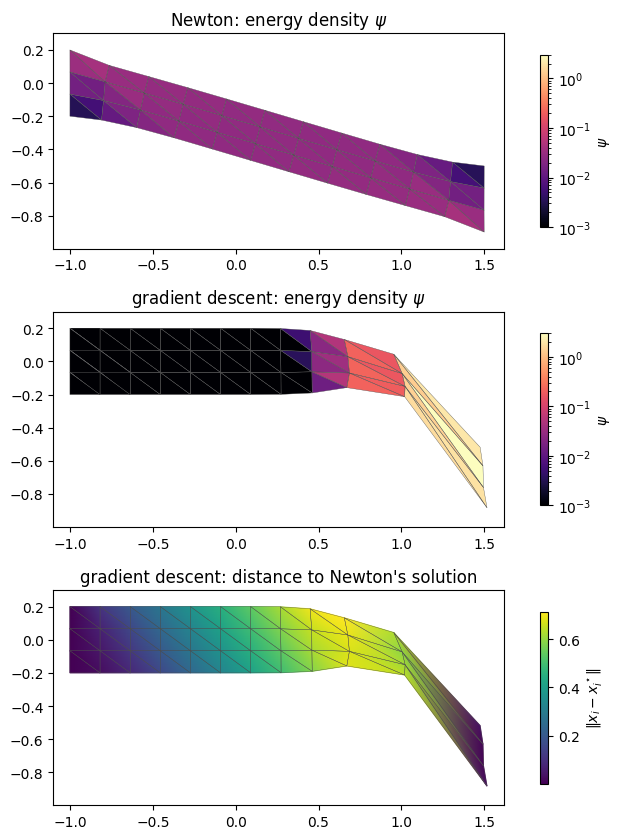

max psi: Newton 0.040, gradient descent 2.952; max vertex error of gradient descent 0.715


In [11]:
F_newton = (J @ x_star).reshape(-1, dim, dim)       # per-element F, as in the energy
F_gd = (J @ gd_xs[-1]).reshape(-1, dim, dim)
psi_newton = simkit.energies.elastic_energy_element_F(F_newton, mu, lam, MATERIAL).ravel()
psi_gd = simkit.energies.elastic_energy_element_F(F_gd, mu, lam, MATERIAL).ravel()
gd_error = np.linalg.norm((gd_xs[-1] - x_star).reshape(n, dim), axis=1)

lims = utils.auto_limits([x_star.reshape(n, dim), gd_xs[-1].reshape(n, dim)], pad=0.1)
fig, axes = plt.subplots(3, 1, figsize=(7.5, 8.5))
utils.plot_scalar_field(axes[0], x_star.reshape(n, dim), T, psi_newton, lims=lims, cmap="magma",
                        norm=LogNorm(*PSI_RANGE), title=r"Newton: energy density $\psi$", label=r"$\psi$")
utils.plot_scalar_field(axes[1], gd_xs[-1].reshape(n, dim), T, psi_gd, lims=lims, cmap="magma",
                        norm=LogNorm(*PSI_RANGE), title=r"gradient descent: energy density $\psi$",
                        label=r"$\psi$")
utils.plot_scalar_field(axes[2], gd_xs[-1].reshape(n, dim), T, gd_error, lims=lims,
                        title=r"gradient descent: distance to Newton's solution",
                        label=r"$\|x_i - x_i^\star\|$")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "energy_density.png"),
                              copy_to=os.path.join(MEDIA_DIR, "005_energy_density.png"))
plt.show()
print(f"max psi: Newton {psi_newton.max():.3f}, gradient descent {psi_gd.max():.3f}; "
      f"max vertex error of gradient descent {gd_error.max():.3f}")

Newton spreads a gentle bend along the whole beam (peak $\psi = 0.04$), while gradient descent
packs the strain into a kink by the handle (peak $\psi = 2.95$), leaves the pinned half unstrained,
and is off by up to 0.72 just before the kink.

### Takeaways
* **Newton** uses curvature and converges *quadratically*, which is ideal for stiff elasticity.
* **Gradient descent** ignores curvature, gets tiny line-search steps, and stalls.
* The **Newton decrement** is a clean, scale-aware stopping measure.
* The Newton *step length* still needs care, which is the subject of tutorial 6.